# 内輪向け機械学習コンペ サンプル ノートブック

## ライブラリをインポート

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error as MSE

## コンペ配布データ読み込み

### 学習用データ読み込み

In [2]:
train_df = pd.read_csv(f"./data/train.csv")

In [3]:
train_df

,id,a,b,c,target
0,1,1,10,100,1
1,2,2,20,200,2
2,3,3,30,300,3
3,4,4,40,400,4
4,5,5,50,500,5
5,6,6,60,600,6
6,7,7,70,700,7
7,8,8,80,800,8
8,9,9,90,900,9
9,10,10,100,1000,10


### 評価用データ読み込み

In [4]:
test_df = pd.read_csv(f"./data/test.csv")

In [5]:
test_df

,id,a,b,c
0,101,1,10,100
1,102,2,20,200
2,103,3,30,300
3,104,4,40,400
4,105,5,50,500
5,106,6,60,600
6,107,7,70,700
7,108,8,80,800
8,109,9,90,900
9,110,10,100,1000


### サンプル投稿ファイル読み込み

In [6]:
submit = pd.read_csv(f"./data/sample_submission.csv")

In [7]:
submit

,id,target
0,101,1
1,102,1
2,103,1
3,104,1
4,105,1
5,106,1
6,107,1
7,108,1
8,109,1
9,110,1


## 前処理

### 説明変数、目的変数に分割

In [8]:
X = train_df[["a", "b"]]
y = train_df["c"]

In [9]:
X

,a,b
0,1,10
1,2,20
2,3,30
3,4,40
4,5,50
5,6,60
6,7,70
7,8,80
8,9,90
9,10,100


In [10]:
y

0     100
1     200
2     300
3     400
4     500
5     600
6     700
7     800
8     900
9    1000
Name: c, dtype: int64

In [11]:
X_test = test_df[["a", "b"]]

In [12]:
X_test

,a,b
0,1,10
1,2,20
2,3,30
3,4,40
4,5,50
5,6,60
6,7,70
7,8,80
8,9,90
9,10,100


### 訓練用データ、検証用データに分割

In [13]:
X_train, X_eval, y_train, y_eval = train_test_split(X, y)

In [14]:
X_train

,a,b
0,1,10
2,3,30
5,6,60
6,7,70
7,8,80
1,2,20
4,5,50


In [15]:
y_train

0    100
2    300
5    600
6    700
7    800
1    200
4    500
Name: c, dtype: int64

In [16]:
X_eval

,a,b
8,9,90
3,4,40
9,10,100


In [17]:
y_eval

8     900
3     400
9    1000
Name: c, dtype: int64

## モデルを訓練

In [18]:
model = LR()

In [19]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 訓練済みモデルによる予測（検証用データ）

In [20]:
y_pred_eval = model.predict(X_eval)

In [21]:
y_pred_eval

array([ 900.,  400., 1000.])

予測精度の可視化

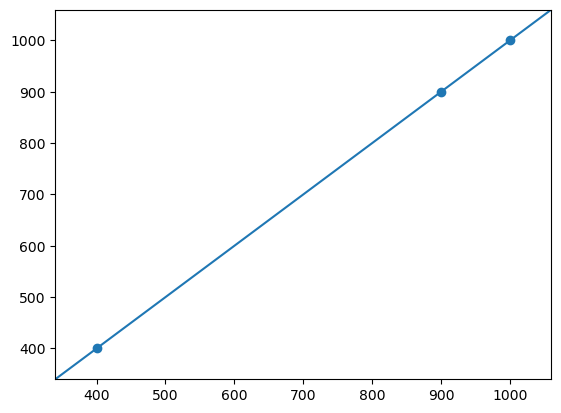

In [22]:
plt.scatter(y_eval, y_pred_eval)

y_eval_min = np.min(y_eval)
y_eval_max = np.max(y_eval)
y_pred_eval_min = np.min(y_pred_eval)
y_pred_eval_max = np.max(y_pred_eval)
y_min = np.minimum(y_eval_min, y_pred_eval_min)
y_max = np.maximum(y_eval_max, y_pred_eval_max)

y_range = y_max - y_min

lim_min = y_min - (y_range * 0.1)
lim_max = y_max + (y_range * 0.1)

plt.xlim([lim_min, lim_max])
plt.ylim([lim_min, lim_max])

plt.plot([lim_min, lim_max], [lim_min, lim_max])

plt.show()

In [23]:
mse_eval = MSE(y_eval, y_pred_eval)
rmse_eval = np.sqrt(mse_eval)

In [24]:
f"{rmse_eval=}"

'rmse_eval=np.float64(1.8852829216231156e-13)'

## 訓練済みモデルによる予測（評価用データ）

In [25]:
y_pred_test = model.predict(X_test)

In [26]:
y_pred_test

array([ 100.,  200.,  300.,  400.,  500.,  600.,  700.,  800.,  900.,
       1000.])

## 採点用投稿ファイル作成

In [27]:
submit["target"] = y_pred_test

In [28]:
submit

,id,target
0,101,100.0
1,102,200.0
2,103,300.0
3,104,400.0
4,105,500.0
5,106,600.0
6,107,700.0
7,108,800.0
8,109,900.0
9,110,1000.0


In [29]:
submit.to_csv("submit.csv", index=False)